In [ ]:
!pip install pytesseract
!pip install opencv-python
!pip install matplotlib
!pip install tensorflow

Required Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import cv2
import pytesseract

STEP 1: Load MNIST dataset

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train / 255.0
X_test = X_test / 255.0
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


STEP 2: Training parameters

In [ ]:
batch_sizes = [32, 64, 128, 256]
epochs_list = [10, 15, 20]
results = {}

STEP 3: Train model

In [ ]:
for batch in batch_sizes:
    for ep in epochs_list:

        print("\n===================================")
        print(f"Training with Batch Size={batch}, Epochs={ep}")
        print("===================================")

        model = Sequential()
        model.add(Dense(10, activation='softmax', input_shape=(784,)))

        model.compile(
            optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        history = model.fit(
            X_train,
            y_train,
            epochs=ep,
            batch_size=batch,
            verbose=1
        )

        loss, acc = model.evaluate(X_test, y_test, verbose=0)

        print("Test Accuracy:", acc)

        results[(batch, ep)] = history.history['accuracy']



Training with Batch Size=32, Epochs=10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8130 - loss: 0.7295
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9134 - loss: 0.3102
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9199 - loss: 0.2851
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9219 - loss: 0.2779
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9261 - loss: 0.2647
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9282 - loss: 0.2595
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9276 - loss: 0.2595
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9308 - loss: 0.2533
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9277 - loss: 0.2567
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9290 - loss: 0.2529
Test Accuracy: 0.9280999898910522

Training with Batch Size=32, Epochs=15
Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 

STEP 4: Visualization

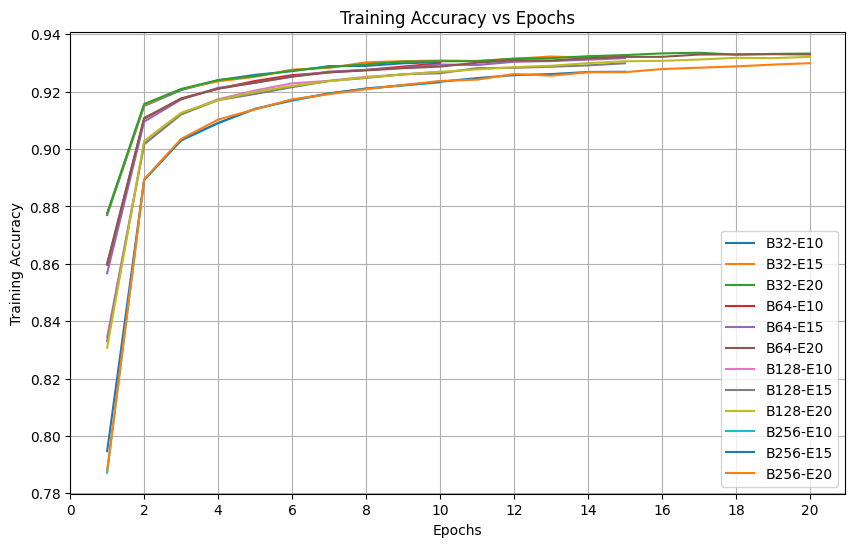

In [ ]:
plt.figure(figsize=(10,6))
for key, acc in results.items():
    batch, ep = key
    plt.plot(range(1, len(acc)+1), acc, label=f"B{batch}-E{ep}")
plt.title("Training Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Training Accuracy")
plt.xticks(range(0,21,2))
plt.legend()
plt.grid(True)
plt.show()

STEP 5: Handwritten Text Detection

Saving WhatsApp Image 2026-03-09 at 5.13.08 PM (1).jpeg to WhatsApp Image 2026-03-09 at 5.13.08 PM (1).jpeg


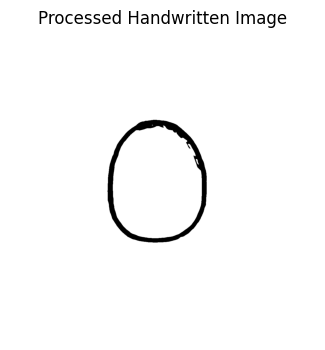


Detected Handwritten Text:
---------------------------
O


In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pytesseract

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

gray = cv2.GaussianBlur(gray,(5,5),0)

_, thresh = cv2.threshold(gray,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(6,4))
plt.imshow(thresh, cmap="gray")
plt.title("Processed Handwritten Image")
plt.axis("off")
plt.show()

custom_config = r'--oem 3 --psm 6 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789'

text = pytesseract.image_to_string(thresh, config=custom_config)
print("\nDetected Handwritten Text:")
print("---------------------------")
print(text.strip())